<a href="https://colab.research.google.com/github/EvanVedh/YOLO_Model_Train/blob/master/YOLO_Model_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Enabling GPU Acceleration**

Click on the **Runtime** menu in the Google Colab toolbar.

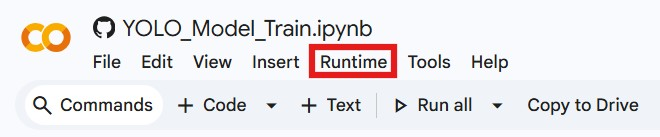

Click on the **Change Runtime Type** on the drop-down menu.

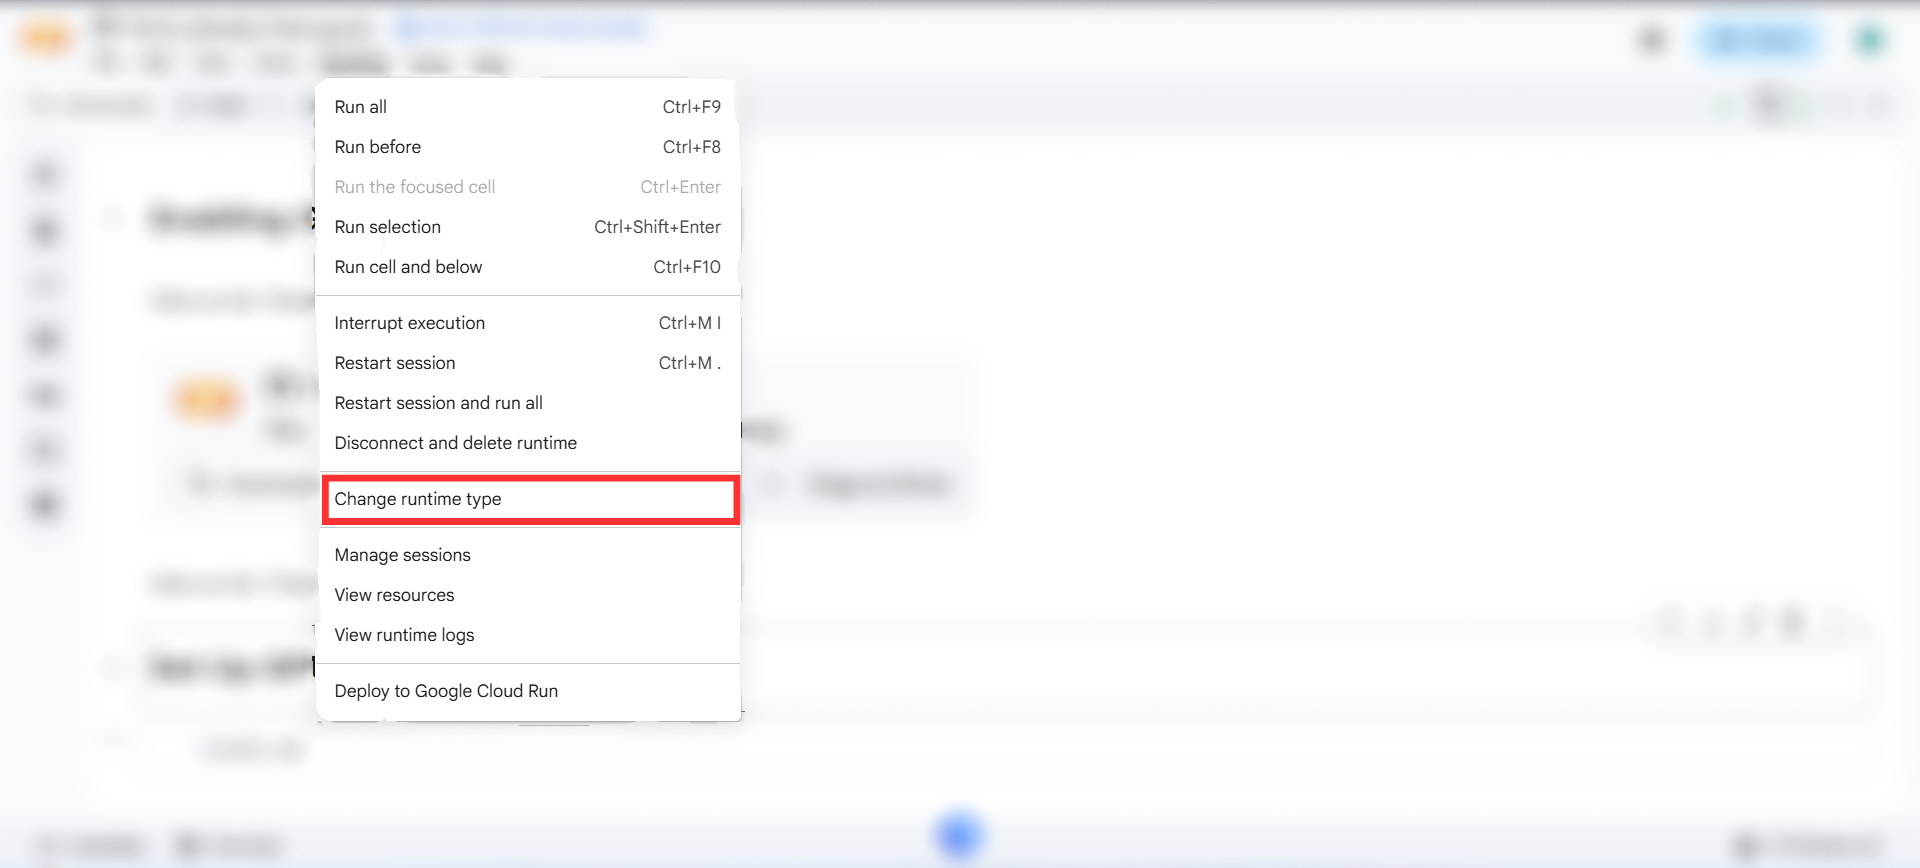

Make sure to select **T4 GPU** and click on **Save.**

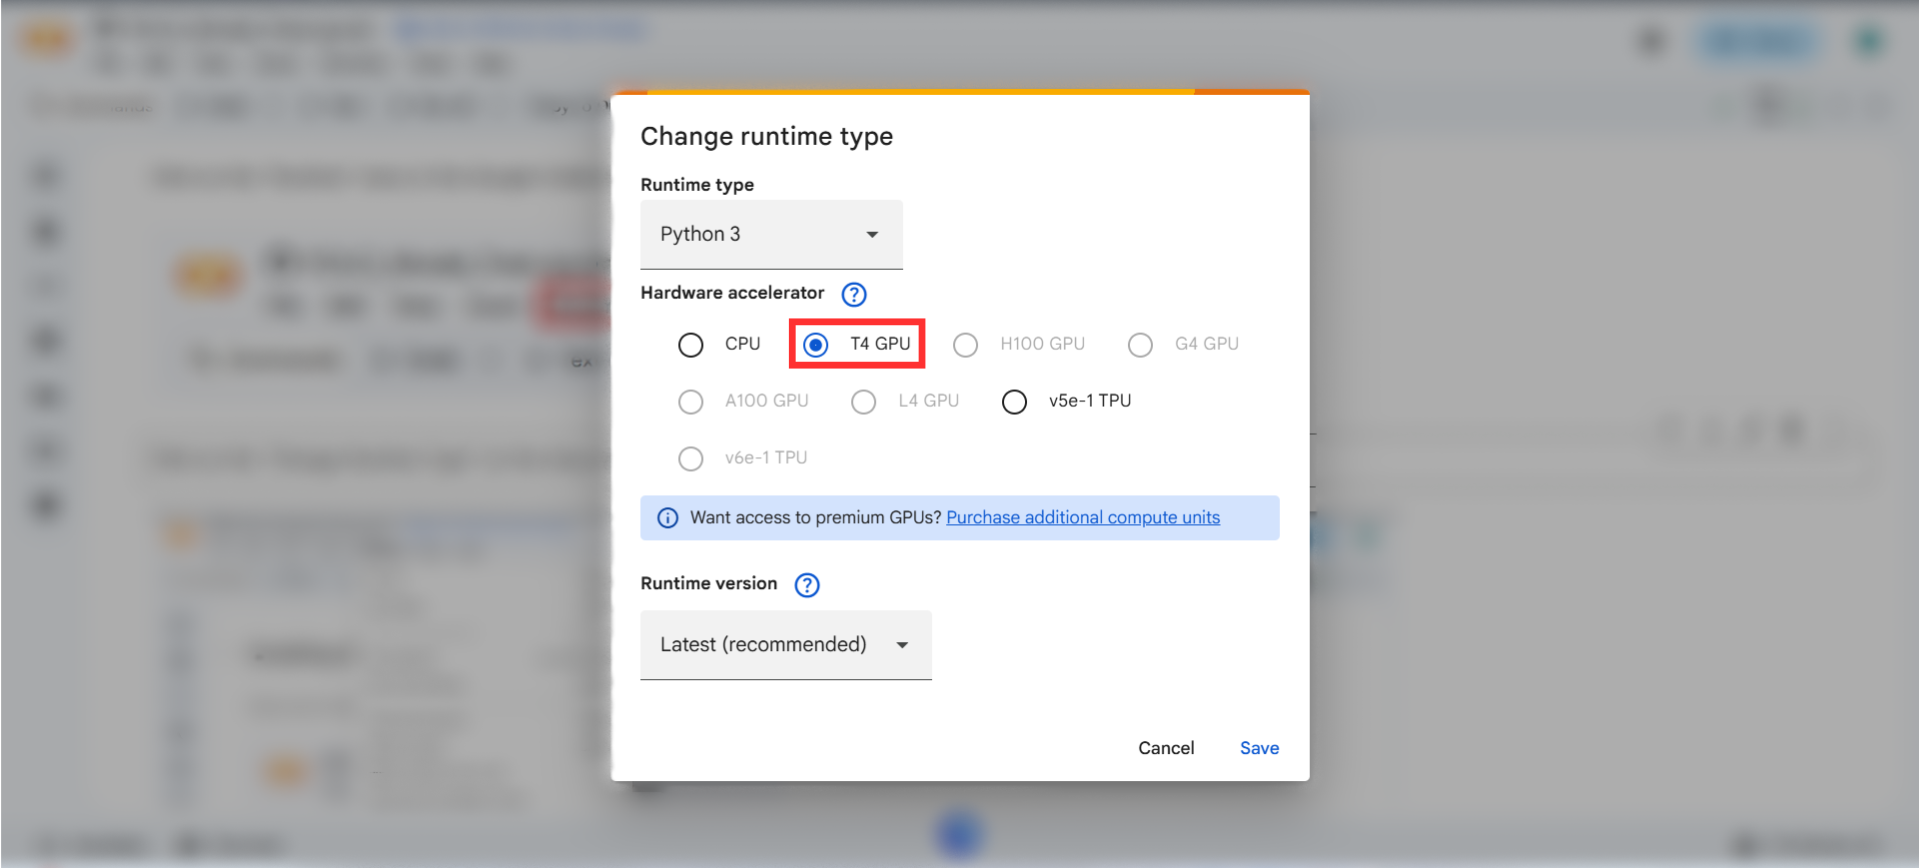

# **Set Up GPU Runtime**

In [ ]:
!nvidia-smi

# **Dataset Partitioning & Pre-processing (80/20 Split)**

In [ ]:
import os
import shutil
import random
import zipfile
from sklearn.model_selection import train_test_split

zip_path = '/content/dataset.zip'
extract_path = '/content/raw_data'
base_dir = '/content/datasets'

print("--- Execution Started ---")

if not os.path.exists(zip_path):
    print(f"ERROR: The file '{zip_path}' was not found. Please upload your zip file to the Colab files tab.")
else:
    print(f"Found '{zip_path}'. Starting extraction...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extraction complete: Files saved to {extract_path}")

    print("--- Setting up YOLO folder structure ---")
    for folder in ['images/train', 'images/val', 'labels/train', 'labels/val']:
        os.makedirs(os.path.join(base_dir, folder), exist_ok=True)
    print(f"Folders created at {base_dir}")

    classes_file = os.path.join(extract_path, 'classes.txt')
    if not os.path.exists(classes_file):
        classes_file = os.path.join(extract_path, 'labels', 'classes.txt')

    if os.path.exists(classes_file):
        with open(classes_file, 'r') as f:
            class_names = [line.strip() for line in f.readlines() if line.strip()]
        print(f"Detected {len(class_names)} classes: {class_names}")
    else:
        class_names = []
        print("ERROR: 'classes.txt' not found in zip root or labels folder.")

    raw_images_dir = os.path.join(extract_path, 'images')
    raw_labels_dir = os.path.join(extract_path, 'labels')

    if not os.path.exists(raw_images_dir) or not os.path.exists(raw_labels_dir):
        print(f"ERROR: Missing 'images' or 'labels' subfolder inside the zip.")
    else:
        images = [f for f in os.listdir(raw_images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

        if len(images) == 0:
            print("ERROR: No images found in the 'images' folder.")
        else:
            train_files, val_files = train_test_split(images, test_size=0.20, random_state=42)

            def move_files(files, subset):
                count = 0
                for f in files:
                    shutil.move(os.path.join(raw_images_dir, f), os.path.join(base_dir, f'images/{subset}/{f}'))
                    label_f = f.rsplit('.', 1)[0] + '.txt'
                    label_src = os.path.join(raw_labels_dir, label_f)
                    if os.path.exists(label_src):
                        shutil.move(label_src, os.path.join(base_dir, f'labels/{subset}/{label_f}'))
                        count += 1
                return count

            print(f"--- Moving files (80/20 split) ---")
            t_count = move_files(train_files, 'train')
            v_count = move_files(val_files, 'val')

            print("\n" + "="*40)
            print("COMPLETION SUMMARY:")
            print(f"Total Images: {len(images)}")
            print(f"Train Set:    {len(train_files)} images, {t_count} labels moved.")
            print(f"Val Set:      {len(val_files)} images, {v_count} labels moved.")
            print("Status:       Ready for Training.")
            print("="*40)

# **Install Ultralytics and Configure YAML**

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from google.colab import files

names_dict = {i: name for i, name in enumerate(class_names)}

yaml_content = f"""
path: /content/datasets
train: images/train
val: images/val
names: {names_dict}
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

# **Train the Model**

In [ ]:
!yolo detect train data=/content/data.yaml model=yolo26s.pt epochs=60 imgsz=640

# **Print Predictions**

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train/weights/best.pt')
results = model.predict(source='datasets/images/val', save=True, conf=0.5)

In [ ]:
import glob
from IPython.display import Image, display

print("--- Training Metrics ---")
for metric_path in glob.glob('/content/runs/detect/train/*.png'):
    display(Image(filename=metric_path, width=800))
    print('\n')

print("--- Sample Predictions ---")
for image_path in glob.glob('/content/runs/detect/predict/*.jpg')[:10]:
    display(Image(filename=image_path, height=400))
    print('\n')

# **Zip and Download Results to PC**

In [ ]:
import shutil
import os
from google.colab import files

source_weights = '/content/runs/detect/train/weights/best.pt'
source_dir = '/content/runs/detect/train'
dest_folder = '/content/trained_model'

os.makedirs(dest_folder, exist_ok=True)
shutil.copy(source_weights, f"{dest_folder}/my_model.pt")
if os.path.exists(f"{dest_folder}/train"): shutil.rmtree(f"{dest_folder}/train")
shutil.copytree(source_dir, f"{dest_folder}/train")

shutil.make_archive('/content/trained_model', 'zip', dest_folder)
files.download('/content/trained_model.zip')